# 01 Exploratory Data Analysis

**Goal:** Understand the raw data before any modelling decisions.

Covers: schema & missingness, churn rate over time, raw numeric signals,
raw categorical signals, rare label analysis, and initial IV scan.

All transforms applied here are **stateless** (domain maps only).
No call/usage feature engineering — that lives in `02_feature_engineering.ipynb`.

In [13]:
import subprocess, sys
for pkg in ['feature-engine', 'scikit-learn', 'pyarrow', 'duckdb', 'xgboost']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

from src.config import PREDICTION_HORIZON_DAYS
from src.ingestion import load_raw_data, build_labels, clean_grain
from src.features import transform_all_categorical, _parse_tech, _parse_bundle
from src.evaluation import categorical_target_summary, iv_band

## 1. Load Raw Data

In [3]:
customer_info, calls, cease, usage_monthly = load_raw_data('.')

./customer_info.parquet: (3545538, 12)  |  202,782 customers


./calls.csv: (628437, 5)  |  128,833 customers
./cease.csv: (146363, 5)  |  130,934 customers
Aggregating usage via DuckDB (83M rows)...


usage_monthly: (3168691, 7)


  usage_monthly: dropped 1 IDs not in customer_info


## 2. Labels & Grain

Binary label: `label=1` if customer places a cease within 90 days of the observation snapshot.
`DATA_END` is derived from the max cease date in the data i.e. no hard coded cutoff.

In [4]:
df, DATA_END = build_labels(customer_info, cease, PREDICTION_HORIZON_DAYS)
df = clean_grain(df)
print(f'DATA_END: {DATA_END.date()}')

Removed 244,436 already-churned rows. Remaining: 3,301,102
Max cease date in data  : 2024-09-01  (derived, not hard-coded)
Right-censoring guard   : DATA_END = 2024-05-01
Label window closes     : 2024-07-30
Buffer before max cease : 33 days

Overall churn rate (all data)         : 11.01%
Churn rate (DATA_END-clean rows only) : 11.38%


Exact duplicate rows: 8,620  -> dropping


Conflicting (customer, datevalue) rows after exact dedupe: 0


Grain check passed -- 3,292,482 unique (customer, month) rows.
DATA_END: 2024-05-01


 Rather than hard-coding a cutoff, DATA_END is derived from the data itself: `MAX_CEASE_DATE − 90 days` (rounded back to a month start). Any snapshot in the final three months cannot be fully labelled yet, so a customer might place a cease after the extract was pulled and would be wrongly recorded as a stay. Skipping this guard quietly inflates apparent accuracy.

### Apply stateless categorical transforms

1) Contract status to 3-bucket risk group.
2) Technology to legacy/standard_fibre/next_gen.
3) Sales channel to consolidated 8 groups. 
4) Package name to tech/bundle parsed columns.

In [16]:
for col in ['contract_status', 'technology', 'sales_channel', 'crm_package_name']:
    df[col] = df[col].fillna('Missing')
df = transform_all_categorical(df)

df['package_tech']        = df['crm_package_name'].apply(_parse_tech)
df['package_bundle_type'] = df['crm_package_name'].apply(_parse_bundle)
_top_pkgs = set(df['crm_package_name'].value_counts().nlargest(10).index)
df['crm_package_grouped'] = df['crm_package_name'].apply(
    lambda x: x if x in _top_pkgs else 'Other_Package')

## 3. Schema & Missingness

In [17]:
print(f'Shape: {df.shape}   |   {df["unique_customer_identifier"].nunique():,} unique customers')
print(f'Date range: {df["datevalue"].min().date()} to {df["datevalue"].max().date()}  ({df["datevalue"].nunique()} months)')
print()
print('Column dtypes:')
print(df.dtypes.to_string())
print()
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    print('Missing values:')
    print(pd.DataFrame({'n': miss, 'pct': (miss / len(df) * 100).round(2)}).to_string())

Shape: (3292482, 24)   |   202,071 unique customers
Date range: 2022-08-01 to 2024-09-01  (26 months)

Column dtypes:
unique_customer_identifier            object
datevalue                     datetime64[ns]
contract_status                       object
contract_dd_cancels                    int64
dd_cancel_60_day                       int32
ooc_days                             float64
technology                            object
speed                                  int32
line_speed                           float64
sales_channel                         object
crm_package_name                      object
tenure_days                            int32
label                                   int8
contract_status_clean                 object
contract_status_risk                  object
technology_clean                      object
technology_group                      object
is_legacy_tech                          int8
sales_channel_group                   object
is_digital_acquisition     

## 4. Overview Charts

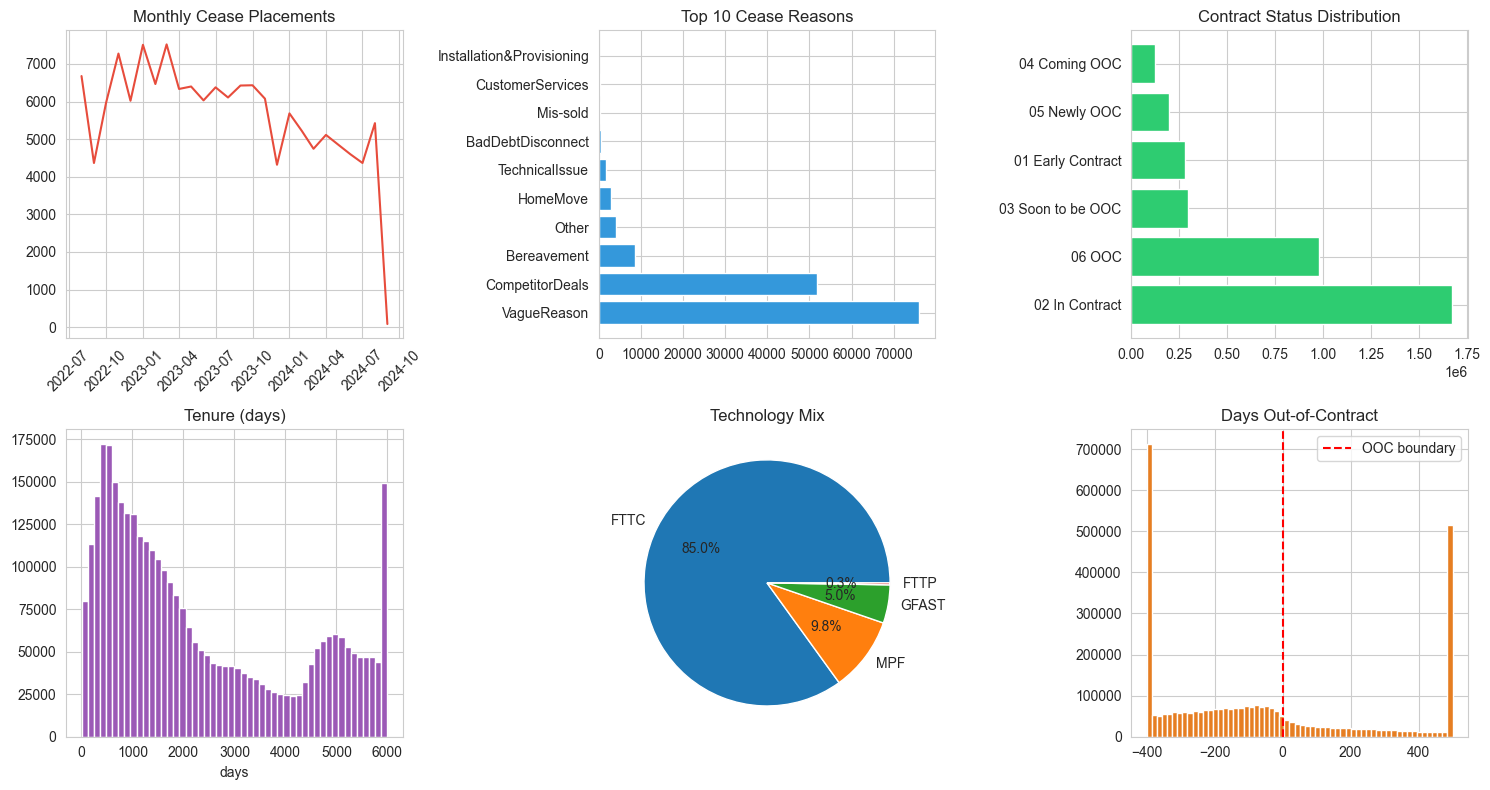

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cease_ts = cease.groupby(cease['cease_placed_date'].dt.to_period('M')).size()
cease_ts.index = cease_ts.index.to_timestamp()
axes[0, 0].plot(cease_ts.index, cease_ts.values, color='#e74c3c')
axes[0, 0].set_title('Monthly Cease Placements'); axes[0, 0].tick_params(axis='x', rotation=45)

reason_counts = cease['reason_description_insight'].value_counts().head(10)
axes[0, 1].barh(reason_counts.index, reason_counts.values, color='#3498db')
axes[0, 1].set_title('Top 10 Cease Reasons')

cs_counts = customer_info['contract_status'].value_counts()
axes[0, 2].barh(cs_counts.index, cs_counts.values, color='#2ecc71')
axes[0, 2].set_title('Contract Status Distribution')

axes[1, 0].hist(customer_info['tenure_days'].clip(0, 6000), bins=50,
                color='#9b59b6', edgecolor='white')
axes[1, 0].set_title('Tenure (days)'); axes[1, 0].set_xlabel('days')

tech_counts = customer_info['technology'].value_counts()
axes[1, 1].pie(tech_counts.values, labels=tech_counts.index, autopct='%1.1f%%')
axes[1, 1].set_title('Technology Mix')

axes[1, 2].hist(customer_info['ooc_days'].clip(-400, 500).dropna(), bins=60,
                color='#e67e22', edgecolor='white')
axes[1, 2].axvline(0, color='red', linestyle='--', label='OOC boundary')
axes[1, 2].set_title('Days Out-of-Contract'); axes[1, 2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Churn Rate Over Time

The right-censoring guard (`DATA_END`) removes the last 3 months where label=1 cannot yet be determined. Ceases placed after the data extract cannot be seen.

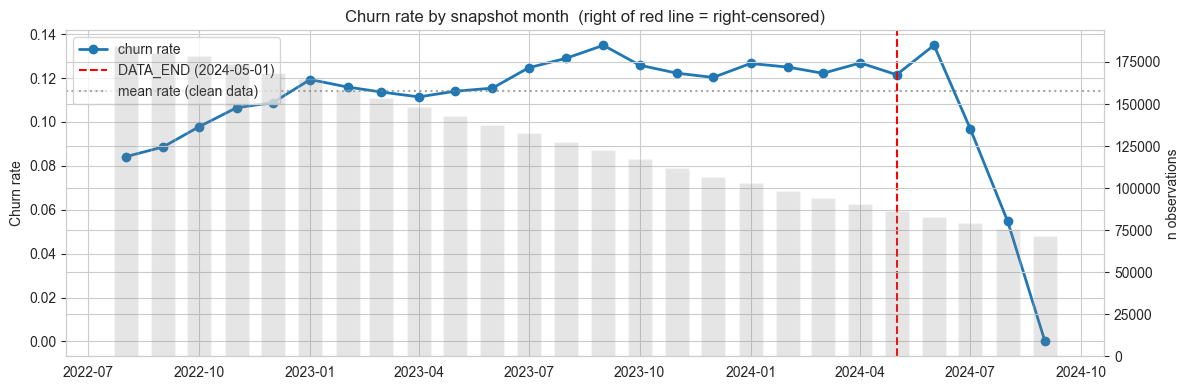

In [8]:
churn_ts = df.groupby('datevalue')['label'].agg(['mean', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(churn_ts['datevalue'], churn_ts['mean'], marker='o', color='C0', lw=2, label='churn rate')
ax1.axvline(DATA_END, color='red', linestyle='--', linewidth=1.5, label=f'DATA_END ({DATA_END.date()})')
ax1.axhline(df[df['datevalue'] <= DATA_END]['label'].mean(),
            color='grey', linestyle=':', alpha=0.7, label='mean rate (clean data)')
ax1.set_ylabel('Churn rate'); ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.bar(churn_ts['datevalue'], churn_ts['count'], width=20, alpha=0.2, color='grey')
ax2.set_ylabel('n observations')
plt.title('Churn rate by snapshot month  (right of red line = right-censored)')
plt.tight_layout(); plt.show()

The steady ~12% line is the true signal; the near-zero tail after the red DATA_END marker is a labelling artifact, not customers suddenly becoming loyal. This visually reflects why we exclude those months from modelling.

## 6. Numeric Signal vs Target

Key signals visible even before feature engineering:
- `ooc_days` signal is **non-monotonic**: approaching-OOC customers churn at ~37.5%, but long-term OOC survivors churn at only ~13%, people leave right as the contract ends; those who stay OOC long-term are sticky. Raw class means (stay: 116d, churn: 136d) barely differ, so the signal shows up as a threshold effect rather than a linear trend
- `tenure_days` lower for churners, newer customers churn faster
- `contract_dd_cancels` and `dd_cancel_60_day` both elevated for churners

Mean by target class:
label                    Stay     Churn
tenure_days         2501.1750 1553.9276
ooc_days             116.1963  135.6784
speed                 55.2294   59.0399
line_speed            50.4019   41.0669
contract_dd_cancels    0.0160    0.2139
dd_cancel_60_day       0.0043    0.1472


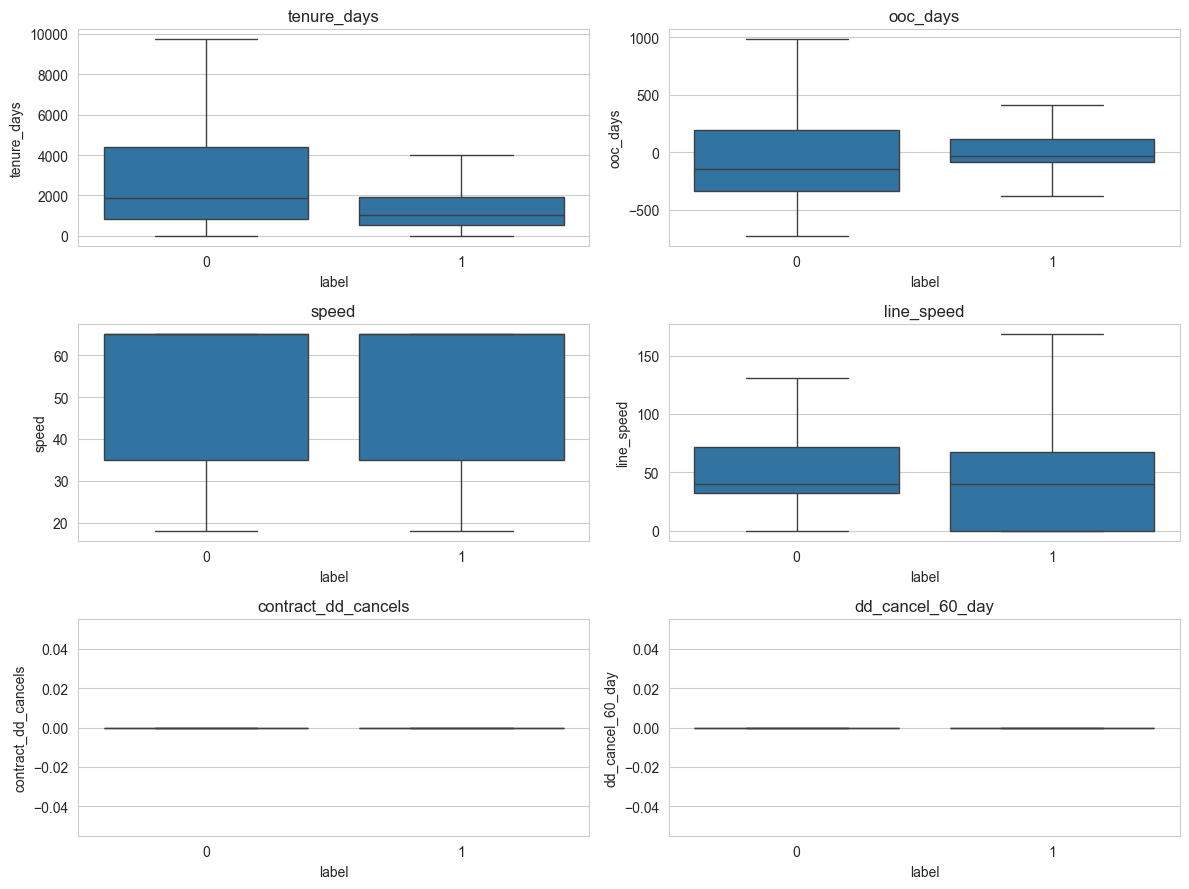

In [9]:
num_cols_eda = ['tenure_days', 'ooc_days', 'speed', 'line_speed',
                'contract_dd_cancels', 'dd_cancel_60_day']

print('Mean by target class:')
print(df.groupby('label')[num_cols_eda].mean().T
        .rename(columns={0: 'Stay', 1: 'Churn'}).to_string())

nrows = (len(num_cols_eda) + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(12, 3 * nrows))
axes = axes.flatten()
for ax, col in zip(axes, num_cols_eda):
    sns.boxplot(data=df, x='label', y=col, ax=ax, showfliers=False)
    ax.set_title(col)
for ax in axes[len(num_cols_eda):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

Raw class means barely differ (stay: 116 days, churn: 136 days), yet ooc_days is the model's best feature. The contract-status breakdown below explains why: customers approaching end of contract churn at 37.5%; those already long term OOC churn at only 13%. People leave right as the contract ends; long-OOC survivors are sticky. The signal is a threshold effect, not a linear trend, which is exactly why gradient boosted trees outperform logistic regression on this data as shown later.

## 7. Categorical Signal vs Target

Raw churn rate per category (before any encoding)

In [10]:
cat_cols_eda = ['contract_status', 'technology', 'sales_channel']

for col in cat_cols_eda:
    n_unique = df[col].nunique()
    churn_by_cat = (
        df.groupby(col)['label']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'churn_rate', 'count': 'n'})
        .sort_values('churn_rate', ascending=False)
    )
    print(f'\n{col}  ({n_unique} unique values):')
    print(churn_by_cat.head(15).to_string())


contract_status  (6 unique values):
                   churn_rate        n
contract_status                       
04 Coming OOC          0.3756   112827
03 Soon to be OOC      0.3568   279776
05 Newly OOC           0.2257   184623
06 OOC                 0.1005   965399
01 Early Contract      0.0506   227063
02 In Contract         0.0462  1522794

technology  (4 unique values):
            churn_rate        n
technology                     
FTTP            0.3074     3786
FTTC            0.1103  2791567
MPF             0.1102   326826
GFAST           0.1039   170303



sales_channel  (13 unique values):
                    churn_rate       n
sales_channel                         
Online - Affiliate      0.1732  756473
Partners                0.1579  273165
Webchat                 0.1313   73436
Online - Ambient        0.1220  171923
Online - Search         0.1195  274216
Retail                  0.1089  207454
Inbound                 0.0994  439558
Online - Other          0.0921   29209
Field                   0.0823   37834
Outbound                0.0702   24270
Unknown                 0.0641  421852
Other                   0.0495    3760
Migrated Customer       0.0418  579332


## 8. Rare Label Analysis

Rare levels in call_type any category below 1% frequency will be grouped
by RareLabelEncoder inside the pipeline.

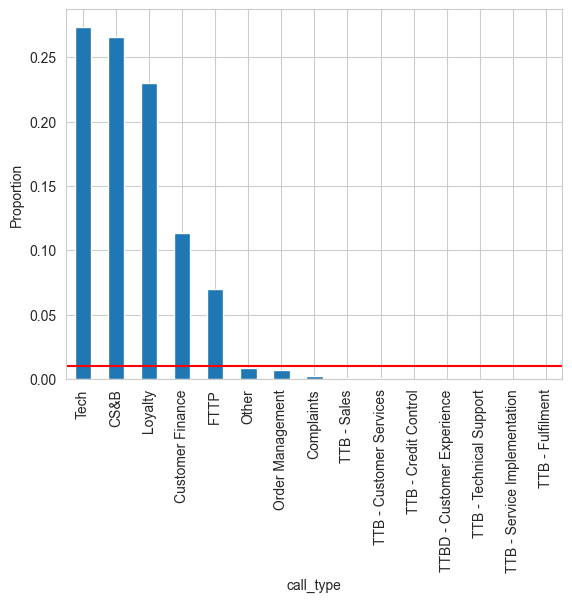

In [11]:
def analyse_rare_labels(data, col, rare_perc=0.01):
    temp_df = pd.Series(data[col].value_counts() / len(data))
    fig = temp_df.sort_values(ascending=False).plot.bar()
    fig.set_xlabel(col)
    fig.axhline(y=rare_perc, color='red')
    fig.set_ylabel('Proportion')
    plt.show()

cat_cols_calls = [c for c in calls.columns
                  if calls[c].dtype == 'object' and c != 'unique_customer_identifier']
for var in cat_cols_calls:
    analyse_rare_labels(calls, var)

## 9. IV Scan (Engineered Categoricals)

Information Value measures separation power per feature. All six engineered cats
evaluated on the right censoring clean slice (no validation split here full IV
stability analysis with train/val split is in the `02_feature_engineering.ipynb`) notebook.

In [12]:
CAT_COLS = [
    'contract_status_risk', 'technology_group', 'sales_channel_group',
    'crm_package_grouped', 'package_tech', 'package_bundle_type',
]

df_clean = df[df['datevalue'] <= DATA_END].copy()

rows = []
for col in CAT_COLS:
    iv = categorical_target_summary(df_clean, col)['iv_contrib'].sum()
    rows.append({'feature': col, 'IV': iv, 'band': iv_band(iv),
                 'cardinality': df_clean[col].nunique()})

iv_df = pd.DataFrame(rows).sort_values('IV', ascending=False).reset_index(drop=True)
print('IV summary (right-censoring-clean data):')
print(iv_df.to_string(index=False))

# Per-category churn rates for top features
for col in CAT_COLS[:3]:
    print(f'\n--- {col} ---')
    print(categorical_target_summary(df_clean, col)
              [['n', 'events', 'mean_target', 'woe', 'iv_contrib']].to_string())

IV summary (right-censoring-clean data):
             feature     IV           band  cardinality
contract_status_risk 0.8284     suspicious            3
 sales_channel_group 0.2323         medium            8
 crm_package_grouped 0.0403           weak           11
        package_tech 0.0195 not predictive            8
 package_bundle_type 0.0173 not predictive            6
    technology_group 0.0002 not predictive            3

--- contract_status_risk ---
                            n  events  mean_target     woe  iv_contrib
contract_status_risk                                                  
approaching_ooc        356192  133657       0.3752 -1.5420      0.4769
ooc                    991466  128639       0.1297 -0.1486      0.0078
in_contract           1635188   77374       0.0473  0.9506      0.3437

--- technology_group ---


                        n  events  mean_target     woe  iv_contrib
technology_group                                                  
legacy             289883   33733       0.1164 -0.0245      0.0001
standard_fibre    2535077  288891       0.1140 -0.0008      0.0000
next_gen           157886   17046       0.1080  0.0599      0.0002

--- sales_channel_group ---
                           n  events  mean_target     woe  iv_contrib
sales_channel_group                                                  
Partners              254807   39929       0.1567 -0.3688      0.0134
Online               1117919  175047       0.1566 -0.3679      0.0584
Webchat                67421    8962       0.1329 -0.1765      0.0008
Retail                187773   20949       0.1116  0.0231      0.0000
Inbound               396252   40767       0.1029  0.1138      0.0016
Other                  84811    7292       0.0860  0.3119      0.0025
Unknown               370666   24820       0.0670  0.5826      0.0337
Migrat

 **`contract_status_risk` IV = 0.83 ("suspicious" band).** This is not leakage, contract status is genuinely known at snapshot time. But it is mechanically close to the outcome, and the model will lean heavily on it. Worth confirming that the model adds value *within* the high-risk contract bands, not just across them. `sales_channel_group` is the only other feature with meaningful IV; `technology_group` carries almost none.